In [1]:
import pandas as pd

In [5]:
file_path = r"C:\Users\I&I Computers\Documents\DataScienceProjects\Customer-Churn-Prediction\data\Telco_customer_churn.xlsx"

df = pd.read_excel(file_path)

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [7]:
df.shape

(7043, 33)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [9]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [10]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [11]:
df['Churn Label'].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [12]:
df['Churn Value'].mean()

np.float64(0.2653698707936959)

In [13]:
df['Churn Value'].mean() * 100

np.float64(26.536987079369588)

In [15]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [16]:
churn_by_contract = df.groupby('Contract')['Churn Value'].sum()
print(churn_by_contract)

Contract
Month-to-month    1655
One year           166
Two year            48
Name: Churn Value, dtype: int64


In [18]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [19]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [21]:
df[df['Total Charges'].isnull()][['Tenure Months', 'Monthly Charges', 'Total Charges']]

,Tenure Months,Monthly Charges,Total Charges
2234,0,52.55,NaN
2438,0,20.25,NaN
2568,0,80.85,NaN
2667,0,25.75,NaN
2856,0,56.05,NaN
4331,0,19.85,NaN
4687,0,25.35,NaN
5104,0,20.00,NaN
5719,0,19.70,NaN
6772,0,73.35,NaN


In [23]:
df['Total Charges'] = df['Total Charges'].fillna(0)

In [24]:
df['Total Charges'].isnull().sum()

np.int64(0)

In [25]:
df[['Monthly Charges', 'Tenure Months', 'Total Charges']].corr()

,Monthly Charges,Tenure Months,Total Charges
Monthly Charges,1.000000,0.247900,0.651174
Tenure Months,0.247900,1.000000,0.826178
Total Charges,0.651174,0.826178,1.000000


In [26]:
df.groupby('Gender')['Churn Value'].mean() * 100

Gender
Female    26.920872
Male      26.160338
Name: Churn Value, dtype: float64

In [27]:
df.groupby('Senior Citizen')['Churn Value'].mean() * 100

Senior Citizen
No     23.606168
Yes    41.681261
Name: Churn Value, dtype: float64

In [28]:
df.groupby(['Senior Citizen', 'Gender'])['Churn Value'].mean() * 100

Senior Citizen  Gender
No              Female    23.938356
                Male      23.280778
Yes             Female    42.253521
                Male      41.114983
Name: Churn Value, dtype: float64

In [29]:
df.groupby('Senior Citizen')['Contract'].value_counts(normalize=True) * 100

Senior Citizen  Contract      
No              Month-to-month    51.991188
                Two year          26.266734
                One year          21.742078
Yes             Month-to-month    70.665499
                One year          16.637478
                Two year          12.697023
Name: proportion, dtype: float64

In [30]:
df.groupby('Contract')['Churn Value'].mean() * 100

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn Value, dtype: float64

In [31]:
# Churn rate by Internet Service
df.groupby('Internet Service')['Churn Value'].mean() * 100

Internet Service
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churn Value, dtype: float64

In [32]:
df.groupby(['Senior Citizen','Internet Service'])['Churn Value'].mean() * 100

Senior Citizen  Internet Service
No              DSL                 17.622572
                Fiber optic         39.911700
                No                   7.327001
Yes             DSL                 30.115830
                Fiber optic         47.292419
                No                   9.615385
Name: Churn Value, dtype: float64

In [33]:
# Total churned revenue loss
total_loss = df[df['Churn Value']==1]['Total Charges'].sum()
total_loss

np.float64(2862926.9)

In [34]:
avg_loss_per_month = df[df['Churn Value']==1]['Monthly Charges'].mean()
avg_loss_per_month

np.float64(74.44133226324237)

In [35]:
# Churn by contract
contract_churn = df.groupby('Contract')['Churn Value'].mean() * 100

# Churn by senior citizen
senior_churn = df.groupby('Senior Citizen')['Churn Value'].mean() * 100

# Churn by internet service
internet_churn = df.groupby('Internet Service')['Churn Value'].mean() * 100

# Combined senior + internet
senior_internet_churn = df.groupby(['Senior Citizen','Internet Service'])['Churn Value'].mean() * 100

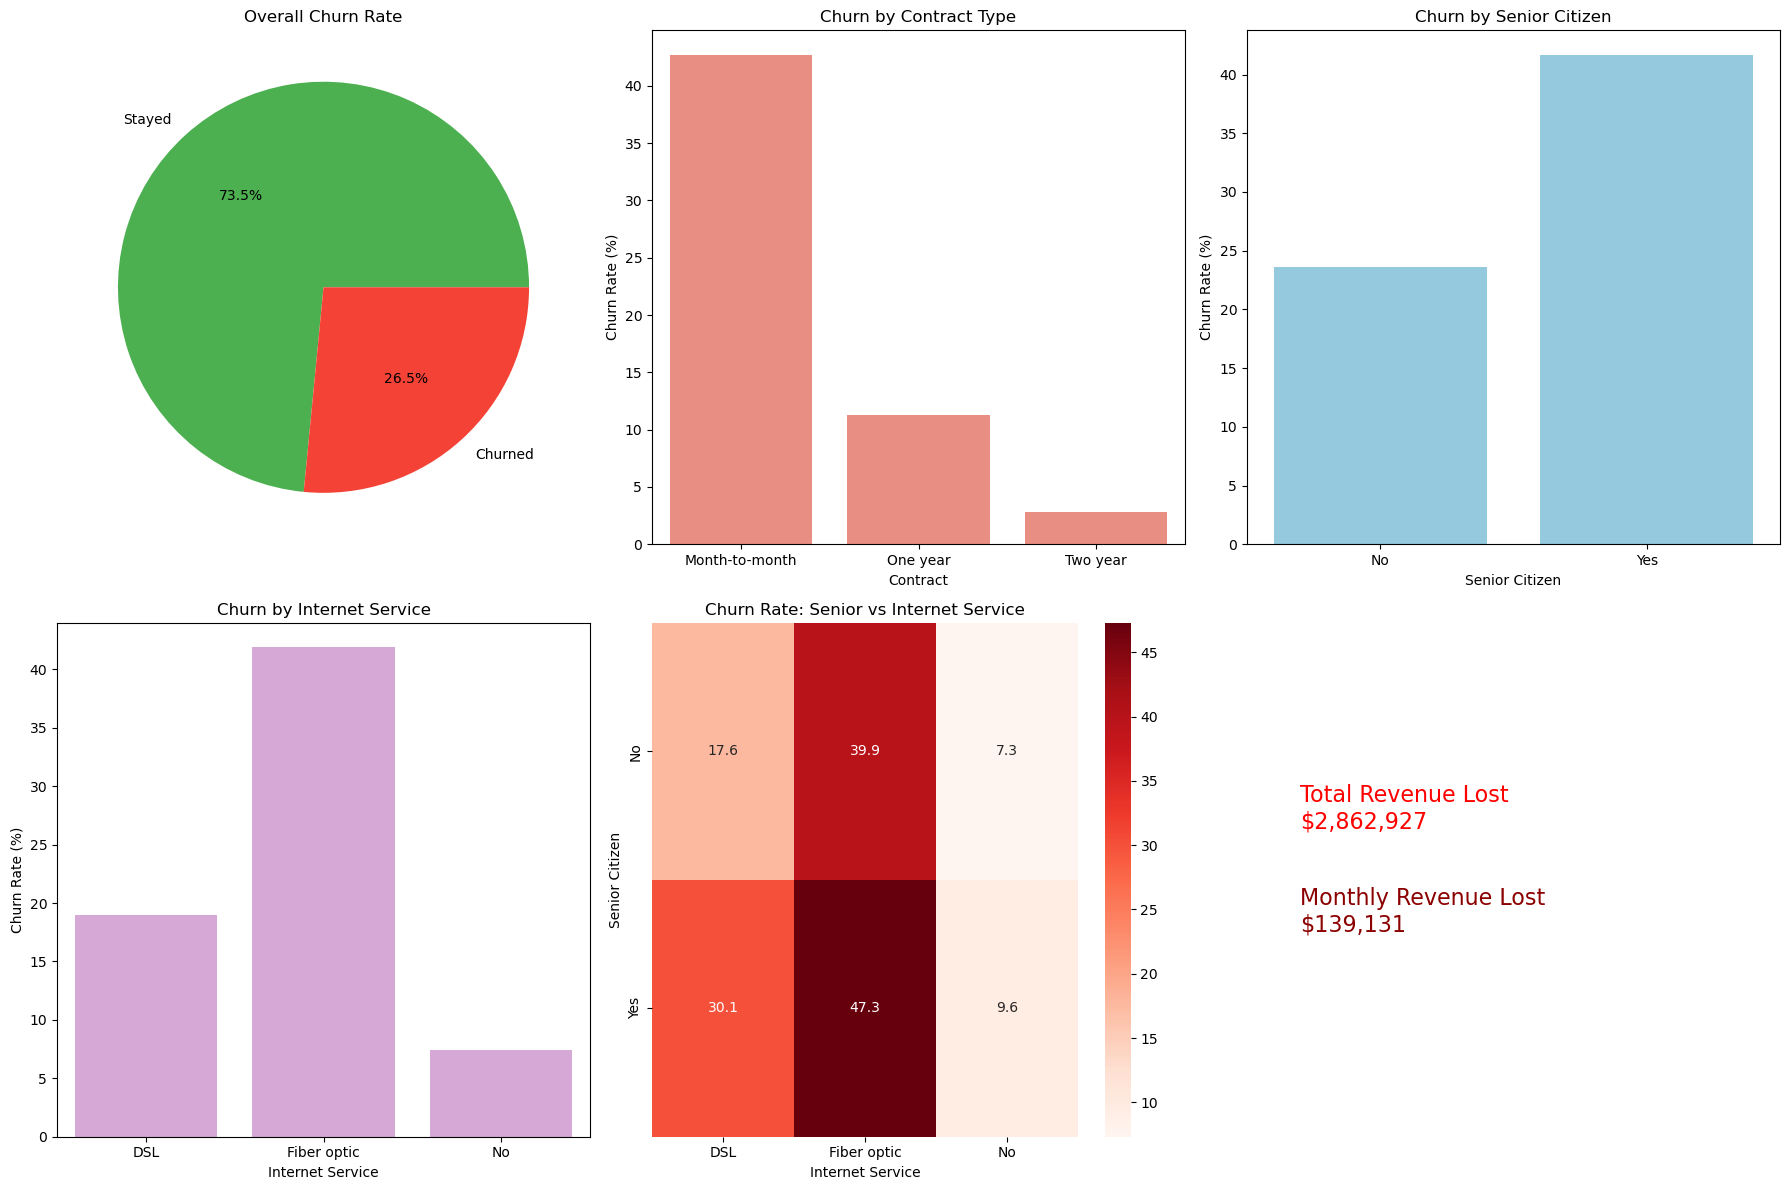

Dashboard saved at: C:\Users\I&I Computers\Documents\DataScienceProjects\Customer-Churn-Prediction\output\churn_dashboard.png


In [37]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Set your output folder
output_folder = r"C:\Users\I&I Computers\Documents\DataScienceProjects\Customer-Churn-Prediction\output"
os.makedirs(output_folder, exist_ok=True)  # Create folder if it doesn't exist

plt.figure(figsize=(18,12))

# 1. Pie chart - overall churn
plt.subplot(2,3,1)
churn_counts = df['Churn Value'].value_counts()
plt.pie(churn_counts, labels=['Stayed','Churned'], autopct='%1.1f%%', colors=['#4CAF50','#F44336'])
plt.title('Overall Churn Rate')

# 2. Bar chart - churn by contract
plt.subplot(2,3,2)
sns.barplot(x=contract_churn.index, y=contract_churn.values, color='salmon')
plt.ylabel('Churn Rate (%)')
plt.title('Churn by Contract Type')

# 3. Bar chart - churn by senior citizen
plt.subplot(2,3,3)
sns.barplot(x=senior_churn.index, y=senior_churn.values, color='skyblue')
plt.ylabel('Churn Rate (%)')
plt.title('Churn by Senior Citizen')

# 4. Bar chart - churn by internet service
plt.subplot(2,3,4)
sns.barplot(x=internet_churn.index, y=internet_churn.values, color='plum')
plt.ylabel('Churn Rate (%)')
plt.title('Churn by Internet Service')

# 5. Heatmap - senior + internet
plt.subplot(2,3,5)
senior_internet_matrix = senior_internet_churn.unstack()
sns.heatmap(senior_internet_matrix, annot=True, fmt=".1f", cmap="Reds")
plt.title('Churn Rate: Senior vs Internet Service')

# 6. Text box - total revenue loss
plt.subplot(2,3,6)
total_loss = df[df['Churn Value']==1]['Total Charges'].sum()
monthly_loss = df[df['Churn Value']==1]['Monthly Charges'].sum()
plt.text(0.1, 0.6, f'Total Revenue Lost\n${total_loss:,.0f}', fontsize=16, color='red')
plt.text(0.1, 0.4, f'Monthly Revenue Lost\n${monthly_loss:,.0f}', fontsize=16, color='darkred')
plt.axis('off')

plt.tight_layout()

# Save the full dashboard as a single image
dashboard_path = os.path.join(output_folder, "churn_dashboard.png")
plt.savefig(dashboard_path, dpi=300)
plt.show()

print(f"Dashboard saved at: {dashboard_path}")

In [38]:
# Monthly revenue loss by Contract Type
contract_loss = df[df['Churn Value']==1].groupby('Contract')['Monthly Charges'].sum()

# Monthly revenue loss by Senior Citizen
senior_loss = df[df['Churn Value']==1].groupby('Senior Citizen')['Monthly Charges'].sum()

# Monthly revenue loss by Internet Service
internet_loss = df[df['Churn Value']==1].groupby('Internet Service')['Monthly Charges'].sum()

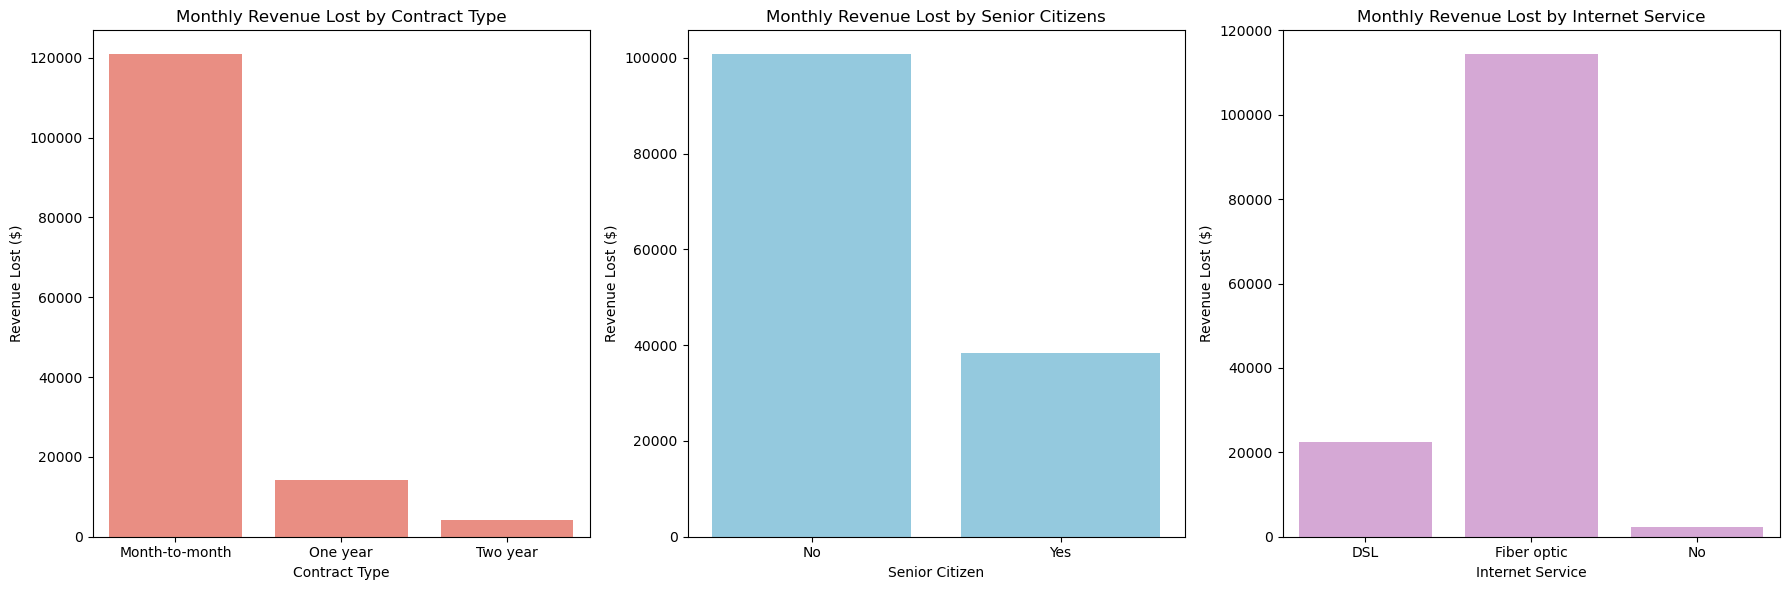

Monthly revenue loss by segments saved at: C:\Users\I&I Computers\Documents\DataScienceProjects\Customer-Churn-Prediction\output\monthly_revenue_loss_segments.png


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Folder to save images
output_folder = r"C:\Users\I&I Computers\Documents\DataScienceProjects\Customer-Churn-Prediction\output"
os.makedirs(output_folder, exist_ok=True)

plt.figure(figsize=(18,6))

# Contract Type
plt.subplot(1,3,1)
sns.barplot(x=contract_loss.index, y=contract_loss.values, color='salmon')
plt.title('Monthly Revenue Lost by Contract Type')
plt.ylabel('Revenue Lost ($)')
plt.xlabel('Contract Type')

# Senior Citizen
plt.subplot(1,3,2)
sns.barplot(x=senior_loss.index, y=senior_loss.values, color='skyblue')
plt.title('Monthly Revenue Lost by Senior Citizens')
plt.ylabel('Revenue Lost ($)')
plt.xlabel('Senior Citizen')

# Internet Service
plt.subplot(1,3,3)
sns.barplot(x=internet_loss.index, y=internet_loss.values, color='plum')
plt.title('Monthly Revenue Lost by Internet Service')
plt.ylabel('Revenue Lost ($)')
plt.xlabel('Internet Service')

plt.tight_layout()

# Save the figure
monthly_loss_path = os.path.join(output_folder, "monthly_revenue_loss_segments.png")
plt.savefig(monthly_loss_path, dpi=300)
plt.show()

print(f"Monthly revenue loss by segments saved at: {monthly_loss_path}")

In [40]:
# Filter only churned customers
churned = df[df['Churn Value']==1]

# Group by Senior, Contract, Internet Service and sum Monthly Charges
segment_loss = churned.groupby(['Senior Citizen', 'Contract', 'Internet Service'])['Monthly Charges'].sum().reset_index()

# Rename for clarity
segment_loss.rename(columns={'Monthly Charges':'Monthly Revenue Lost'}, inplace=True)

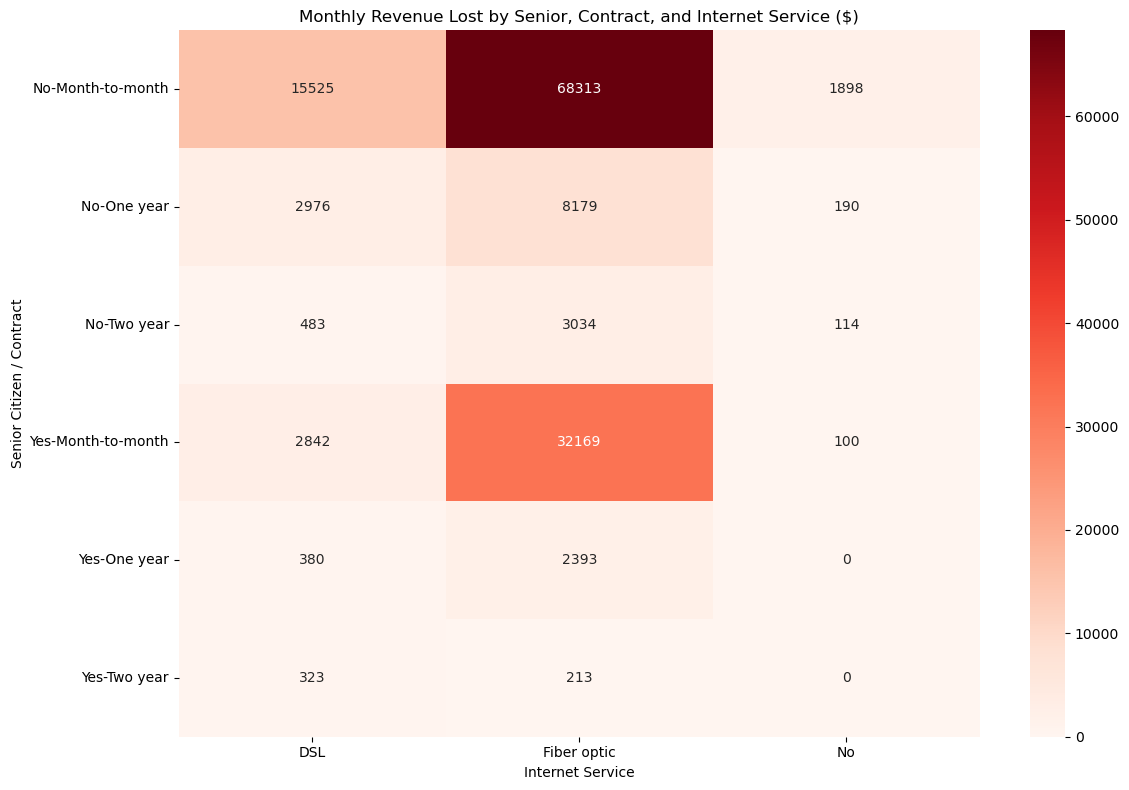

Heatmap saved at: C:\Users\I&I Computers\Documents\DataScienceProjects\Customer-Churn-Prediction\output\monthly_revenue_loss_heatmap.png


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set output folder
output_folder = r"C:\Users\I&I Computers\Documents\DataScienceProjects\Customer-Churn-Prediction\output"
os.makedirs(output_folder, exist_ok=True)

# Pivot for heatmap
heatmap_data = segment_loss.pivot_table(
    index=['Senior Citizen', 'Contract'], 
    columns='Internet Service', 
    values='Monthly Revenue Lost',
    fill_value=0
)

plt.figure(figsize=(12,8))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="Reds")
plt.title("Monthly Revenue Lost by Senior, Contract, and Internet Service ($)")
plt.ylabel("Senior Citizen / Contract")
plt.xlabel("Internet Service")
plt.tight_layout()

# Save the image
heatmap_path = os.path.join(output_folder, "monthly_revenue_loss_heatmap.png")
plt.savefig(heatmap_path, dpi=300)
plt.show()

print(f"Heatmap saved at: {heatmap_path}")

In [47]:
print(df['Senior Citizen'].unique())
print(df['Contract'].unique())
print(df['Internet Service'].unique())

['No' 'Yes']
['Month-to-month' 'Two year' 'One year']
['DSL' 'Fiber optic' 'No']


In [48]:
target = df[
    (df['Senior Citizen'] == 'No') &
    (df['Contract'] == 'Month-to-month') &
    (df['Internet Service'] == 'Fiber optic')
]

print(target.shape)

(1492, 33)


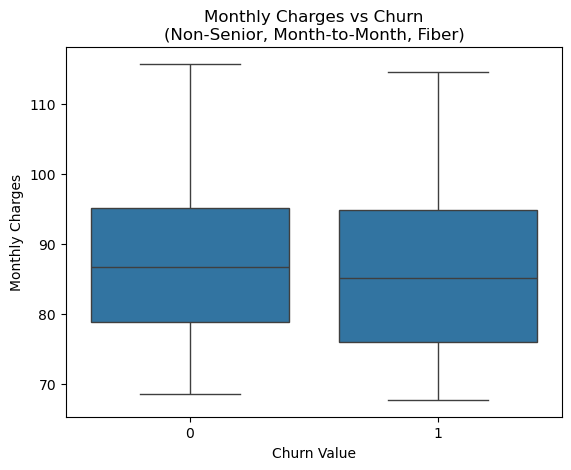

Churn Value
0    87.348496
1    86.036461
Name: Monthly Charges, dtype: float64


In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Churn Value', y='Monthly Charges', data=target)
plt.title("Monthly Charges vs Churn\n(Non-Senior, Month-to-Month, Fiber)")
plt.show()

print(target.groupby('Churn Value')['Monthly Charges'].mean())

In [46]:
print(target.shape)

(0, 33)


<Axes: xlabel='Monthly Charges', ylabel='Density'>

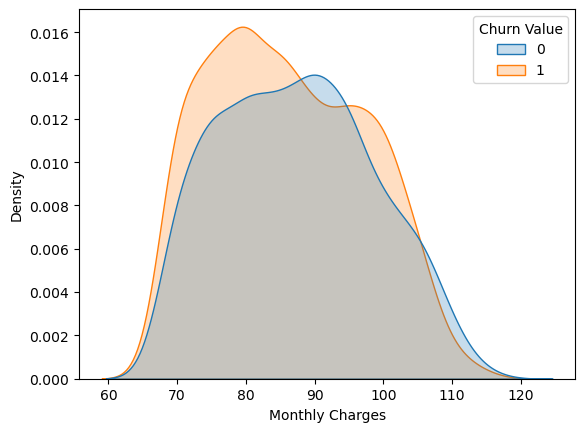

In [51]:
sns.kdeplot(data=target, x='Monthly Charges', hue='Churn Value', fill=True)

In [53]:
print(df.columns)

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')


In [54]:
target.groupby('Churn Value')['Tenure Months'].mean()

Churn Value
0    26.588825
1    14.797229
Name: Tenure Months, dtype: float64

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define tenure bins
bins = [0, 6, 12, 24, 36, 48, 60, 72]
labels = ['0-6','6-12','12-24','24-36','36-48','48-60','60-72']

# Add tenure group column
df['Tenure Group'] = pd.cut(df['Tenure Months'], bins=bins, labels=labels, right=False)

In [57]:
tenure_churn = df.groupby('Tenure Group', observed=True)['Churn Value'].mean() * 100
print(tenure_churn)

Tenure Group
0-6      54.266958
6-12     36.532951
12-24    29.512894
24-36    22.031963
36-48    19.518717
48-60    15.000000
60-72     8.296164
Name: Churn Value, dtype: float64


In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create Tenure Group if not already done
bins = [0, 6, 12, 24, 36, 48, 60, 72]
labels = ['0-6','6-12','12-24','24-36','36-48','48-60','60-72']
df['Tenure Group'] = pd.cut(df['Tenure Months'], bins=bins, labels=labels, right=False)

segment_churn = df.groupby(
    ['Tenure Group', 'Contract', 'Senior Citizen', 'Internet Service'], 
    observed=True  # ✅ add this to remove warning
).agg(
    churn_rate=('Churn Value', 'mean'),
    revenue_lost=('Total Charges', lambda x: x[df.loc[x.index,'Churn Value']==1].sum())
).reset_index()

# Convert churn_rate to percentage
segment_churn['churn_rate'] = segment_churn['churn_rate'] * 100

segment_churn.head()

,Tenure Group,Contract,Senior Citizen,Internet Service,churn_rate,revenue_lost
0,0-6,Month-to-month,No,DSL,47.921760,19017.90
1,0-6,Month-to-month,No,Fiber optic,74.245940,58515.35
2,0-6,Month-to-month,No,No,26.277372,2322.15
3,0-6,Month-to-month,Yes,DSL,72.222222,2878.65
4,0-6,Month-to-month,Yes,Fiber optic,76.388889,19879.85


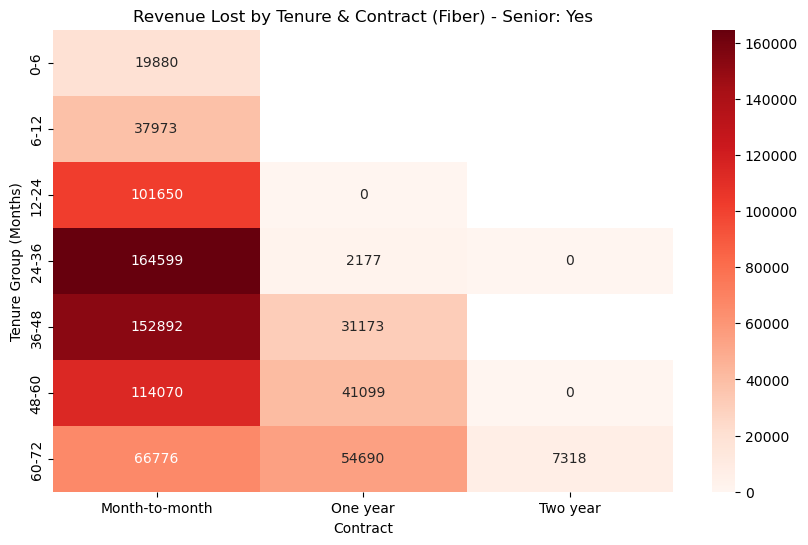

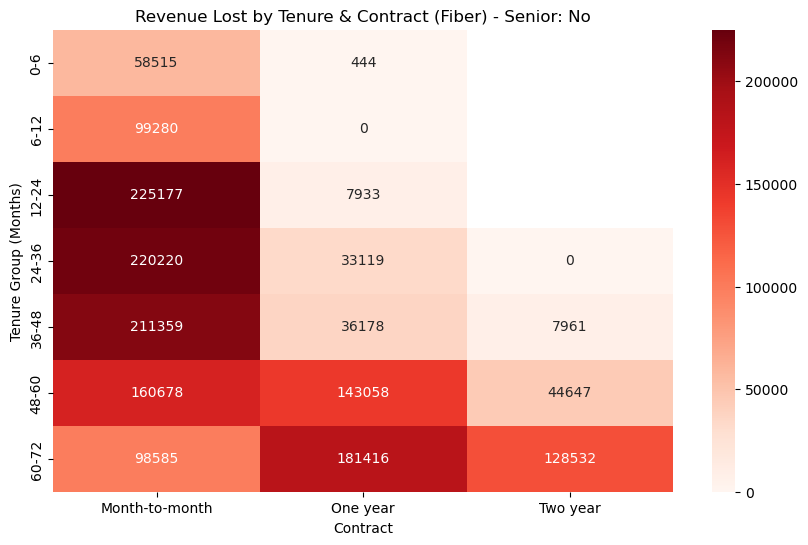

In [60]:
# Filter for Fiber users
fiber_df = segment_churn[segment_churn['Internet Service']=='Fiber optic']

# Pivot for heatmap: Tenure vs Contract, separate heatmaps for Senior/Non-Senior
for senior_status in ['Yes','No']:
    pivot = fiber_df[fiber_df['Senior Citizen']==senior_status].pivot(
        index='Tenure Group', columns='Contract', values='revenue_lost'
    )
    
    plt.figure(figsize=(10,6))
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Reds")
    plt.title(f'Revenue Lost by Tenure & Contract (Fiber) - Senior: {senior_status}')
    plt.ylabel('Tenure Group (Months)')
    plt.show()

In [63]:
# Filter for the segment: Non-Senior, Month-to-Month, Fiber
fiber_non_senior = df[
    (df['Senior Citizen']=='No') & 
    (df['Contract']=='Month-to-month') & 
    (df['Internet Service']=='Fiber optic')
]

# Group by Tenure Group with observed=True to remove warning
revenue_by_tenure = fiber_non_senior.groupby(
    'Tenure Group', 
    observed=True  # ✅ Add this
).agg(
    revenue_lost=('Total Charges', lambda x: x[fiber_non_senior.loc[x.index,'Churn Value']==1].sum()),
    churn_count=('Churn Value', 'sum')  # optional: number of churned customers
).reset_index()

revenue_by_tenure
# Show the results
revenue_by_tenure

,Tenure Group,revenue_lost,churn_count
0,0-6,58515.35,320
1,6-12,99279.60,136
2,12-24,225176.70,152
3,24-36,220219.55,85
4,36-48,211358.85,54
5,48-60,160678.00,32
6,60-72,98584.70,15


In [64]:
# Function to calculate revenue lost and churn count by tenure
def tenure_revenue_table(df_segment):
    return df_segment.groupby('Tenure Group', observed=True).agg(
        revenue_lost=('Total Charges', lambda x: x[df_segment.loc[x.index,'Churn Value']==1].sum()),
        churn_count=('Churn Value', 'sum')
    ).reset_index()

# Filter for Month-to-Month Fiber
fiber_monthly = df[
    (df['Contract']=='Month-to-month') &
    (df['Internet Service']=='Fiber optic')
]

# Non-Senior
non_senior = fiber_monthly[fiber_monthly['Senior Citizen']=='No']
non_senior_table = tenure_revenue_table(non_senior)
non_senior_table['Segment'] = 'Non-Senior'

# Senior
senior = fiber_monthly[fiber_monthly['Senior Citizen']=='Yes']
senior_table = tenure_revenue_table(senior)
senior_table['Segment'] = 'Senior'

# Combine tables for easy comparison
combined_table = pd.concat([non_senior_table, senior_table], ignore_index=True)

combined_table

,Tenure Group,revenue_lost,churn_count,Segment
0,0-6,58515.35,320,Non-Senior
1,6-12,99279.60,136,Non-Senior
2,12-24,225176.70,152,Non-Senior
3,24-36,220219.55,85,Non-Senior
4,36-48,211358.85,54,Non-Senior
5,48-60,160678.00,32,Non-Senior
6,60-72,98584.70,15,Non-Senior
7,0-6,19879.85,110,Senior
8,6-12,37973.45,52,Senior
9,12-24,101649.75,71,Senior


In [65]:
mid_tenure = df[
    (df['Tenure Months'] >= 12) &
    (df['Tenure Months'] <= 48) &
    (df['Churn Value'] == 1)
]

mid_tenure['Churn Reason'].value_counts()

Churn Reason
Attitude of support person                   70
Competitor offered higher download speeds    66
Don't know                                   62
Competitor offered more data                 51
Competitor made better offer                 45
Attitude of service provider                 44
Competitor had better devices                42
Lack of self-service on Website              38
Product dissatisfaction                      38
Service dissatisfaction                      37
Price too high                               34
Network reliability                          26
Extra data charges                           23
Moved                                        20
Lack of affordable download/upload speed     16
Limited range of services                    15
Long distance charges                        11
Poor expertise of phone support              10
Poor expertise of online support              7
Deceased                                      2
Name: count, dtype: int64

In [66]:
df.groupby('Tenure Group')['Monthly Charges'].mean()

C:\Users\I&I Computers\AppData\Local\Temp\ipykernel_15324\366351619.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Tenure Group')['Monthly Charges'].mean()


Tenure Group
0-6      54.590190
6-12     58.935172
12-24    60.853295
24-36    65.127854
36-48    66.430615
48-60    69.735122
60-72    74.296610
Name: Monthly Charges, dtype: float64

In [67]:
mid = df[(df['Tenure Months']>=12) & (df['Tenure Months']<=48)]

mid.groupby('Churn Value')['Monthly Charges'].mean()

Churn Value
0    58.275698
1    81.394368
Name: Monthly Charges, dtype: float64

In [68]:
df[['Monthly Charges', 'Tenure Months', 'Churn Value']].corr()

,Monthly Charges,Tenure Months,Churn Value
Monthly Charges,1.000000,0.247900,0.193356
Tenure Months,0.247900,1.000000,-0.352229
Churn Value,0.193356,-0.352229,1.000000


In [69]:
# Early churn (0–6 months)
early = df[(df['Tenure Months'] <= 6) & (df['Churn Value'] == 1)]
early['Churn Reason'].value_counts()

# Mid churn (12–48 months)
mid = df[(df['Tenure Months'] >= 12) & 
         (df['Tenure Months'] <= 48) & 
         (df['Churn Value'] == 1)]
mid['Churn Reason'].value_counts()

Churn Reason
Attitude of support person                   70
Competitor offered higher download speeds    66
Don't know                                   62
Competitor offered more data                 51
Competitor made better offer                 45
Attitude of service provider                 44
Competitor had better devices                42
Lack of self-service on Website              38
Product dissatisfaction                      38
Service dissatisfaction                      37
Price too high                               34
Network reliability                          26
Extra data charges                           23
Moved                                        20
Lack of affordable download/upload speed     16
Limited range of services                    15
Long distance charges                        11
Poor expertise of phone support              10
Poor expertise of online support              7
Deceased                                      2
Name: count, dtype: int64

In [71]:
# Early churners (0–6 months)
early_churn = df[
    (df['Tenure Months'] <= 6) &
    (df['Churn Value'] == 1)
]

early_reasons = early_churn['Churn Reason'].value_counts()

print("Early Churn Reasons:")
print(early_reasons)


# Mid churners (12–48 months)
mid_churn = df[
    (df['Tenure Months'] >= 12) &
    (df['Tenure Months'] <= 48) &
    (df['Churn Value'] == 1)
]

mid_reasons = mid_churn['Churn Reason'].value_counts()

print("\nMid Churn Reasons:")
print(mid_reasons)

Early Churn Reasons:
Churn Reason
Attitude of support person                   80
Competitor offered higher download speeds    72
Don't know                                   72
Competitor had better devices                64
Competitor made better offer                 63
Attitude of service provider                 63
Competitor offered more data                 58
Network reliability                          45
Price too high                               41
Product dissatisfaction                      41
Service dissatisfaction                      36
Lack of self-service on Website              34
Limited range of services                    21
Long distance charges                        21
Moved                                        21
Extra data charges                           19
Lack of affordable download/upload speed     16
Poor expertise of phone support               7
Poor expertise of online support              7
Deceased                                      3
Name: 

In [72]:
# Mid churners dataframe
mid_churn = df[(df['Tenure Months'] >= 12) & (df['Tenure Months'] <= 48) & (df['Churn Value'] == 1)]

# Group by churn reason and calculate total lost revenue
mid_revenue_loss = mid_churn.groupby('Churn Reason')['Total Charges'].sum().sort_values(ascending=False)

print(mid_revenue_loss)

Churn Reason
Attitude of support person                   146635.55
Don't know                                   137829.60
Competitor offered higher download speeds    133052.60
Competitor made better offer                 113568.20
Competitor offered more data                 110438.15
Attitude of service provider                  97255.90
Competitor had better devices                 86532.10
Product dissatisfaction                       84034.05
Service dissatisfaction                       78094.35
Price too high                                77401.00
Lack of self-service on Website               69242.85
Network reliability                           55590.50
Extra data charges                            52462.65
Moved                                         45601.45
Lack of affordable download/upload speed      37725.05
Limited range of services                     30266.10
Poor expertise of phone support               23950.85
Long distance charges                         19223.

In [73]:
# Create tenure groups
df['Tenure Group'] = pd.cut(
    df['Tenure Months'],
    bins=[0, 6, 12, 24, 48, 72],
    labels=['0-6', '7-12', '13-24', '25-48', '49-72']
)

In [74]:
churned = df[df['Churn Value'] == 1]

In [79]:
segment_revenue = churned.groupby(
    ['Contract', 'Tenure Group', 'Internet Service', 'Senior Citizen'],
    observed=True
)['Total Charges'].sum().reset_index()

In [81]:
segment_revenue = segment_revenue.sort_values(
    by='Total Charges',
    ascending=False
)

segment_revenue.head(10)

,Contract,Tenure Group,Internet Service,Senior Citizen,Total Charges
19,Month-to-month,25-48,Fiber optic,No,414508.90
43,One year,49-72,Fiber optic,No,327119.00
20,Month-to-month,25-48,Fiber optic,Yes,307578.30
24,Month-to-month,49-72,Fiber optic,No,254141.40
14,Month-to-month,13-24,Fiber optic,No,227311.25
51,Two year,49-72,Fiber optic,No,175923.55
25,Month-to-month,49-72,Fiber optic,Yes,175407.60
15,Month-to-month,13-24,Fiber optic,Yes,110447.20
8,Month-to-month,7-12,Fiber optic,No,107504.50
44,One year,49-72,Fiber optic,Yes,95789.85


In [82]:
segment_full = churned.groupby(
    ['Contract', 'Tenure Group', 'Internet Service', 'Senior Citizen']
).agg({
    'Total Charges': 'sum',
    'CustomerID': 'count'
}).reset_index()

segment_full = segment_full.sort_values(
    by='Total Charges',
    ascending=False
)

segment_full.head(10)

C:\Users\I&I Computers\AppData\Local\Temp\ipykernel_15324\102976451.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_full = churned.groupby(


,Contract,Tenure Group,Internet Service,Senior Citizen,Total Charges,CustomerID
20,Month-to-month,25-48,Fiber optic,No,414508.90,130
56,One year,49-72,Fiber optic,No,327119.00,52
21,Month-to-month,25-48,Fiber optic,Yes,307578.30,96
26,Month-to-month,49-72,Fiber optic,No,254141.40,46
14,Month-to-month,13-24,Fiber optic,No,227311.25,143
86,Two year,49-72,Fiber optic,No,175923.55,26
27,Month-to-month,49-72,Fiber optic,Yes,175407.60,32
15,Month-to-month,13-24,Fiber optic,Yes,110447.20,72
8,Month-to-month,7-12,Fiber optic,No,107504.50,132
57,One year,49-72,Fiber optic,Yes,95789.85,15


In [83]:
target_segment = churned[
    (churned['Contract'] == 'Month-to-month') &
    (churned['Tenure Group'] == '25-48') &
    (churned['Internet Service'] == 'Fiber optic') &
    (churned['Senior Citizen'] == 'No')
]

In [84]:
reason_counts = target_segment['Churn Reason'].value_counts()

reason_counts.head(10)

Churn Reason
Don't know                                   16
Attitude of support person                   13
Competitor offered higher download speeds    12
Service dissatisfaction                      11
Competitor offered more data                 10
Competitor made better offer                  9
Attitude of service provider                  9
Extra data charges                            8
Competitor had better devices                 7
Lack of affordable download/upload speed      5
Name: count, dtype: int64

In [85]:
reason_revenue = target_segment.groupby(
    'Churn Reason',
    observed=True
)['Total Charges'].sum().sort_values(ascending=False)

reason_revenue.head(10)

Churn Reason
Don't know                                   51030.70
Attitude of support person                   46189.65
Competitor offered higher download speeds    34448.90
Competitor offered more data                 32689.45
Service dissatisfaction                      32131.30
Competitor made better offer                 30492.85
Attitude of service provider                 30244.40
Extra data charges                           26426.00
Competitor had better devices                25499.25
Price too high                               14114.40
Name: Total Charges, dtype: float64

In [86]:
segment_reason_analysis = target_segment.groupby(
    'Churn Reason',
    observed=True
).agg({
    'Total Charges': 'sum',
    'CustomerID': 'count'
}).sort_values(by='Total Charges', ascending=False)

segment_reason_analysis.head(10)

,Total Charges,CustomerID
Churn Reason,,
Don't know,51030.70,16
Attitude of support person,46189.65,13
Competitor offered higher download speeds,34448.90,12
Competitor offered more data,32689.45,10
Service dissatisfaction,32131.30,11
Competitor made better offer,30492.85,9
Attitude of service provider,30244.40,9
Extra data charges,26426.00,8
Competitor had better devices,25499.25,7


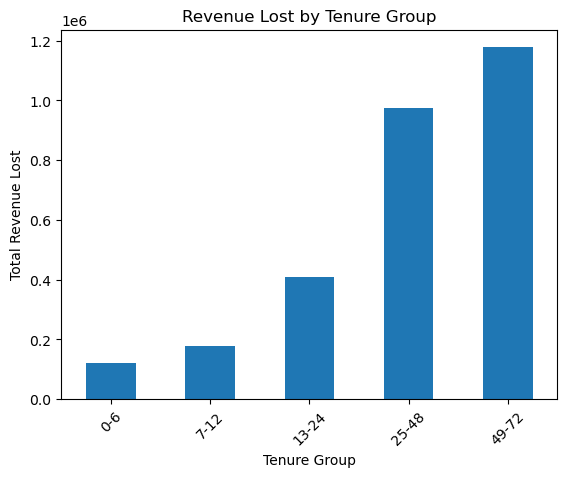

In [87]:
import matplotlib.pyplot as plt

tenure_revenue = churned.groupby(
    'Tenure Group',
    observed=True
)['Total Charges'].sum().sort_index()

plt.figure()
tenure_revenue.plot(kind='bar')
plt.title("Revenue Lost by Tenure Group")
plt.ylabel("Total Revenue Lost")
plt.xlabel("Tenure Group")
plt.xticks(rotation=45)
plt.show()

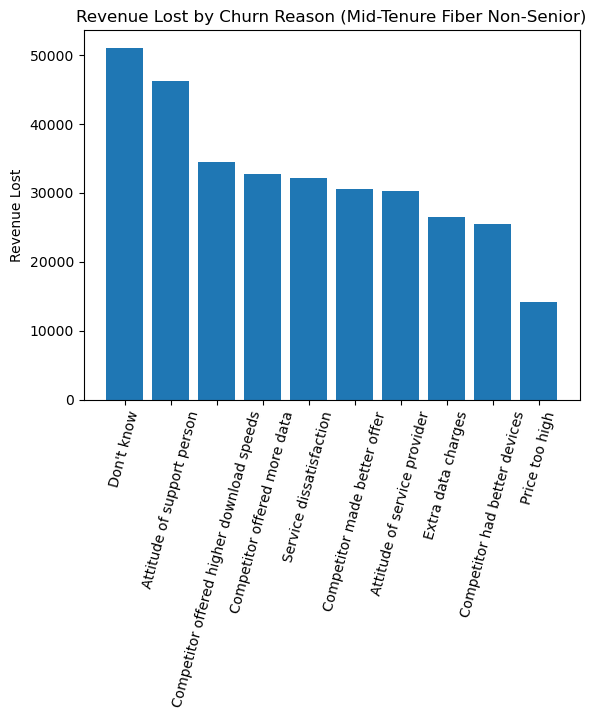

In [88]:
top_reasons = segment_reason_analysis.head(10)

plt.figure()
plt.bar(top_reasons.index, top_reasons['Total Charges'])
plt.xticks(rotation=75)
plt.title("Revenue Lost by Churn Reason (Mid-Tenure Fiber Non-Senior)")
plt.ylabel("Revenue Lost")
plt.show()

In [89]:
churn_rate_tenure = df.groupby(
    'Tenure Group',
    observed=True
)['Churn Value'].mean() * 100

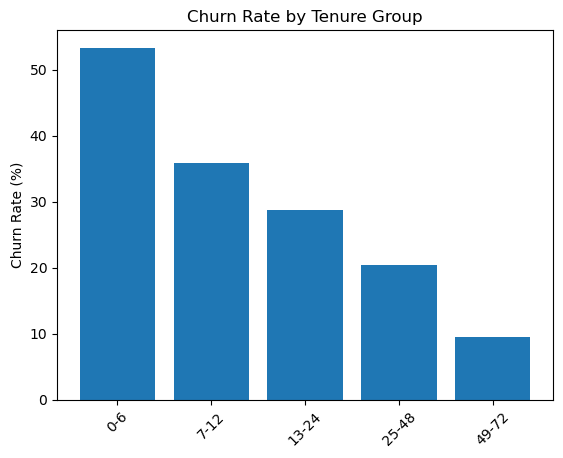

In [90]:
fig, ax1 = plt.subplots()

ax1.bar(churn_rate_tenure.index, churn_rate_tenure.values)
ax1.set_ylabel("Churn Rate (%)")
ax1.set_title("Churn Rate by Tenure Group")
plt.xticks(rotation=45)

plt.show()

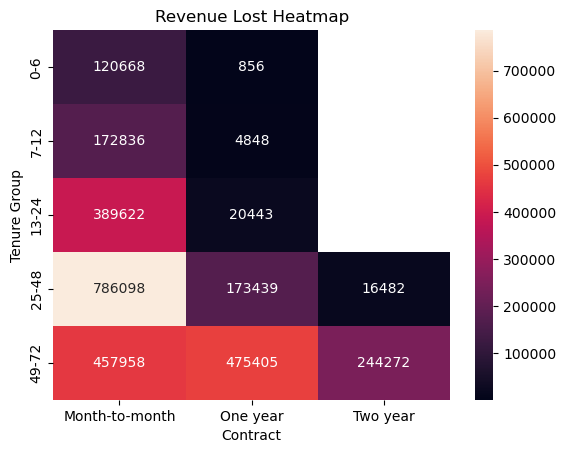

In [91]:
import seaborn as sns

pivot = churned.pivot_table(
    values='Total Charges',
    index='Tenure Group',
    columns='Contract',
    aggfunc='sum',
    observed=True
)

plt.figure()
sns.heatmap(pivot, annot=True, fmt=".0f")
plt.title("Revenue Lost Heatmap")
plt.show()